# Warm-Start Transfer: nx=3,ny=3 vs nx=4,ny=3

This notebook trains an ML warm-start predictor on **nx=3, ny=3** data and
evaluates its effectiveness in two scenarios:

| Scenario | Description |
|----------|-------------|
| **In-distribution** (3x3) | Predictor used on the same grid size it was trained on |
| **Out-of-distribution** (4x3) | Predictor used on a larger grid it has never seen |

For each scenario we compare **warm-start** vs **random initialisation**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.ml_warmstart_vqe import (
    WarmStartCollector,
    WarmStartPredictor,
    benchmark_warmstart,
    plot_warmstart_quality,
)
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_PATH  = os.path.join('..', 'data', 'warmstart_3x3_data.json')
MODEL_DIR  = os.path.join('..', 'warmstart_models_3x3')

## Step 1 — Collect Training Data (nx=3, ny=3)

We run several independent VQE optimisations for TM and TE modes on the
3x3 grid to build our training set.

In [4]:
collector = WarmStartCollector(
    data_path=DATA_PATH,
    Lx=0.015, Ly=0.010,
)

N_RUNS = 5

for mode in ('TM', 'TE'):
    for k in (0, 1):
        print(f'\n-- Collecting {mode} k={k} (vacuum) --')
        collector.collect(
            nx=3, ny=3, n_layers=6,
            mode_type=mode, k=k,
            plasma_density=0.0,
            n_runs=N_RUNS,
        )

NE = 1e17
for mode in ('TM',):
    for k in (0, 1):
        print(f'\n-- Collecting {mode} k={k} (Ne={NE:.0e}) --')
        collector.collect(
            nx=3, ny=3, n_layers=6,
            mode_type=mode, k=k,
            plasma_density=NE,
            n_runs=N_RUNS,
        )

collector.summary()


-- Collecting TM k=0 (vacuum) --
  [nx3_ny3_nl6_mtTM_k0] run 1/5 λ=264057.8968  (136.5s)
  [nx3_ny3_nl6_mtTM_k0] run 2/5 λ=140738.2990  (249.7s)
  [nx3_ny3_nl6_mtTM_k0] run 3/5 λ=140738.2904  (683.7s)
  [nx3_ny3_nl6_mtTM_k0] run 4/5 λ=140738.2904  (282.6s)
  [nx3_ny3_nl6_mtTM_k0] run 5/5 λ=264058.0439  (336.2s)
Collected 5 new samples for 'nx3_ny3_nl6_mtTM_k0' (total: 5)

-- Collecting TM k=1 (vacuum) --
  [nx3_ny3_nl6_mtTM_k1] run 1/5 λ=140738.2867  (249.4s)
  [nx3_ny3_nl6_mtTM_k1] run 2/5 λ=264057.9001  (717.5s)
  [nx3_ny3_nl6_mtTM_k1] run 3/5 λ=264058.0643  (425.3s)
  [nx3_ny3_nl6_mtTM_k1] run 4/5 λ=264057.9412  (565.2s)
  [nx3_ny3_nl6_mtTM_k1] run 5/5 λ=264057.8963  (167.0s)
Collected 5 new samples for 'nx3_ny3_nl6_mtTM_k1' (total: 5)

-- Collecting TE k=0 (vacuum) --
  [nx3_ny3_nl6_mtTE_k0] run 1/5 λ=43304.0882  (177.6s)
  [nx3_ny3_nl6_mtTE_k0] run 2/5 λ=43304.0999  (311.0s)
Attempt 1 - Iter 236: Cost 0.0006        
[Warning] Attempt 1 found eigenvalue 0.0006 (< 1). Restarting...

## Step 2 — Train the Predictor (on 3x3 data)

In [2]:
predictor = WarmStartPredictor(
    data_path=DATA_PATH,
    model_dir=MODEL_DIR,
    max_iter=2000,
)

predictor.train(verbose=True)

print('\nTrained keys:')
for key in predictor.trained_keys():
    print(f'  - {key}')

  Loaded model for 'nx3_ny3_nl6_mtTE_k1'
  Loaded model for 'nx3_ny3_nl6_mtTM_k0'
  Loaded model for 'nx3_ny3_nl6_mtTE_k0'
  Loaded model for 'nx3_ny3_nl6_mtTM_k1'
  Trained 'nx3_ny3_nl6_mtTM_k0'  N=10  hidden=(144, 144)  R²=0.1153
  Trained 'nx3_ny3_nl6_mtTM_k1'  N=10  hidden=(168, 168)  R²=0.1173
  Trained 'nx3_ny3_nl6_mtTE_k0'  N=5  hidden=(144, 144)  R²=0.2303
  Trained 'nx3_ny3_nl6_mtTE_k1'  N=5  hidden=(168, 168)  R²=0.5016

Training complete.  4 model(s) ready.

Trained keys:
  - nx3_ny3_nl6_mtTE_k1
  - nx3_ny3_nl6_mtTM_k0
  - nx3_ny3_nl6_mtTE_k0
  - nx3_ny3_nl6_mtTM_k1


## Step 3 — Quality Diagnostics (3x3)

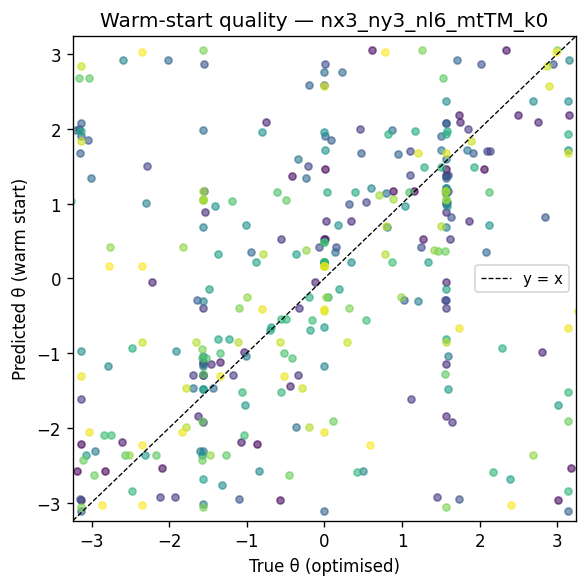

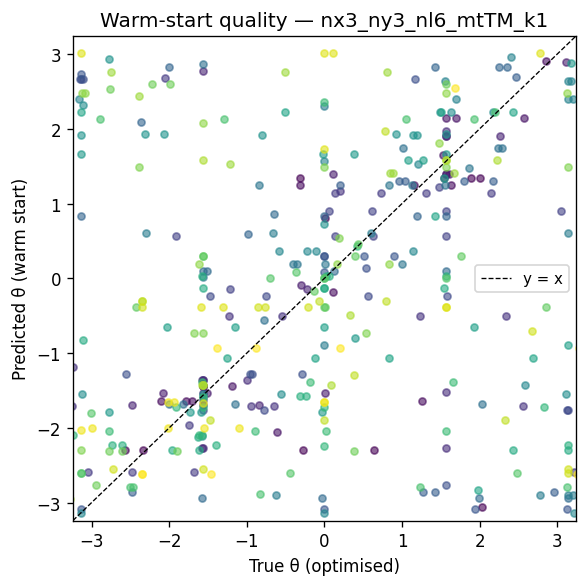

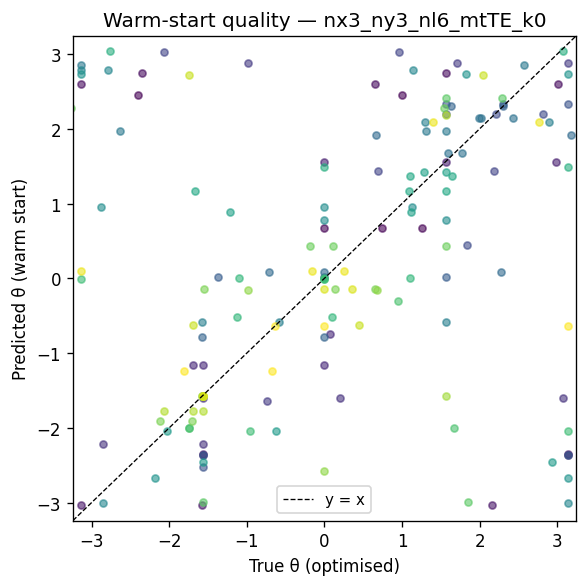

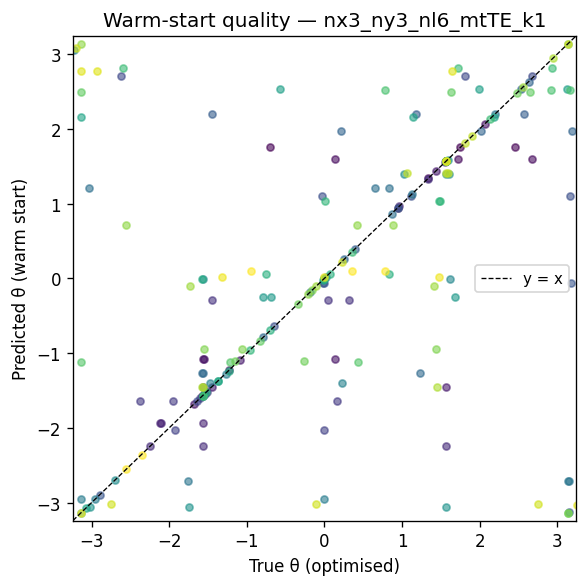

In [3]:
plot_warmstart_quality(DATA_PATH, predictor)

## Step 4 — Benchmark: nx=3, ny=3 (in-distribution)

The predictor was trained on 3x3 data, so this is the **best-case** scenario.


── WARM START  (3 trials) ──
  trial 1: λ=264058.0494  iters=185
  trial 2: λ=140738.3051  iters=131
  trial 3: λ=140738.3159  iters=91

── RANDOM START  (3 trials) ──
  trial 1: λ=264057.9155  iters=197
  trial 2: λ=264057.9126  iters=100
  trial 3: λ=418207.4219  iters=81


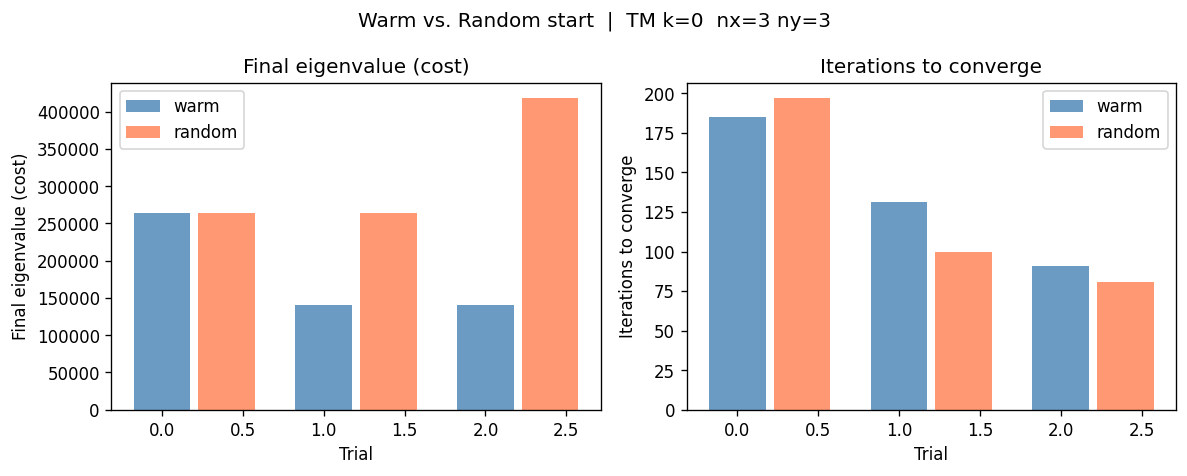

=== nx=3, ny=3  (in-distribution) ===

  WARM START:
    Mean eigenvalue : 181844.8901 +/- 58133.4824
    Mean iterations : 135.7 +/- 38.5

  RANDOM START:
    Mean eigenvalue : 315441.0833 +/- 72666.7748
    Mean iterations : 126.0 +/- 50.8


In [4]:
N_TRIALS = 3

results_3x3 = benchmark_warmstart(
    predictor,
    nx=3, ny=3, n_layers=6,
    mode_type='TM', k=0,
    plasma_density=0.0,
    n_trials=N_TRIALS,
)

print('=== nx=3, ny=3  (in-distribution) ===')
for strat in ('warm', 'random'):
    eigs  = [r[0] for r in results_3x3[strat]]
    iters = [r[1] for r in results_3x3[strat]]
    print(f'\n  {strat.upper()} START:')
    print(f'    Mean eigenvalue : {np.mean(eigs):.4f} +/- {np.std(eigs):.4f}')
    print(f'    Mean iterations : {np.mean(iters):.1f} +/- {np.std(iters):.1f}')

## Step 5 — Benchmark: nx=4, ny=3 (out-of-distribution)

Here the predictor has **never seen** 4x3 data. We test whether the
learned initialisation still transfers to a larger grid.


── WARM START  (3 trials) ──
  trial 1: λ=141158.3782  iters=70
  trial 2: λ=141158.6521  iters=140
  trial 3: λ=270650.6180  iters=193

── RANDOM START  (3 trials) ──
  trial 1: λ=141158.3842  iters=164
  trial 2: λ=141158.3689  iters=205
  trial 3: λ=270650.5534  iters=107


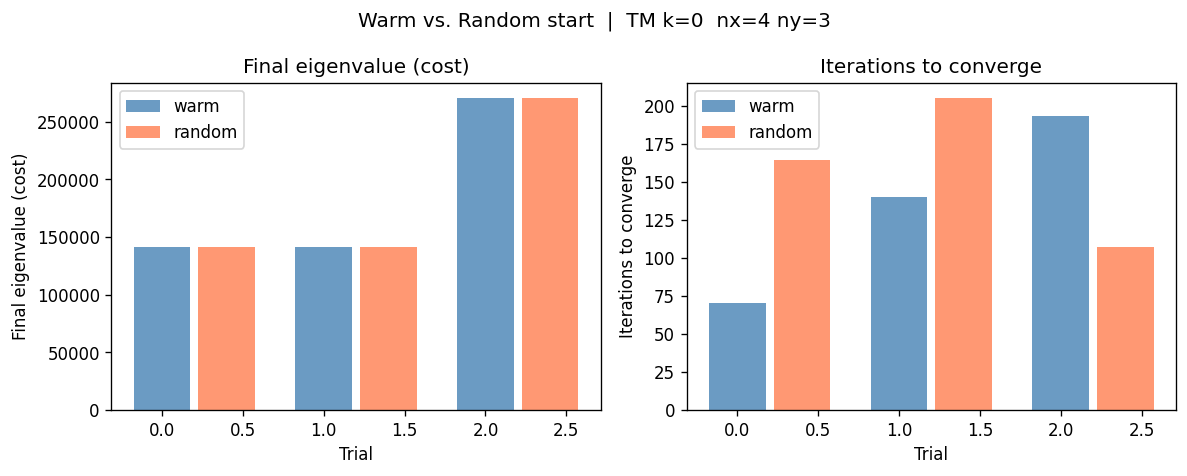

=== nx=4, ny=3  (out-of-distribution) ===

  WARM START:
    Mean eigenvalue : 184322.5494 +/- 61043.1627
    Mean iterations : 134.3 +/- 50.4

  RANDOM START:
    Mean eigenvalue : 184322.4355 +/- 61043.1976
    Mean iterations : 158.7 +/- 40.2


In [5]:
results_4x3 = benchmark_warmstart(
    predictor,
    nx=4, ny=3, n_layers=7,
    mode_type='TM', k=0,
    plasma_density=0.0,
    n_trials=N_TRIALS,
)

print('=== nx=4, ny=3  (out-of-distribution) ===')
for strat in ('warm', 'random'):
    eigs  = [r[0] for r in results_4x3[strat]]
    iters = [r[1] for r in results_4x3[strat]]
    print(f'\n  {strat.upper()} START:')
    print(f'    Mean eigenvalue : {np.mean(eigs):.4f} +/- {np.std(eigs):.4f}')
    print(f'    Mean iterations : {np.mean(iters):.1f} +/- {np.std(iters):.1f}')

## Step 6 — Side-by-Side Comparison

Compare convergence speed and eigenvalue quality across both grid sizes.

In [6]:
# ---- Build summary table ----
summary = {}
for label, res in [('3x3', results_3x3), ('4x3', results_4x3)]:
    for strat in ('warm', 'random'):
        eigs  = [r[0] for r in res[strat]]
        iters = [r[1] for r in res[strat]]
        summary[(label, strat)] = {
            'eig_mean': np.mean(eigs), 'eig_std': np.std(eigs),
            'iter_mean': np.mean(iters), 'iter_std': np.std(iters),
        }

print(f'{"Config":<10} {"Strategy":<10} {"Eigenvalue":>22} {"Iterations":>20}')
print('-' * 65)
for label in ('3x3', '4x3'):
    for strat in ('warm', 'random'):
        s = summary[(label, strat)]
        print(f'{label:<10} {strat:<10} '
              f'{s["eig_mean"]:>12.2f} +/- {s["eig_std"]:<8.2f}'
              f'{s["iter_mean"]:>8.1f} +/- {s["iter_std"]:<6.1f}')

Config     Strategy               Eigenvalue           Iterations
-----------------------------------------------------------------
3x3        warm          181844.89 +/- 58133.48   135.7 +/- 38.5  
3x3        random        315441.08 +/- 72666.77   126.0 +/- 50.8  
4x3        warm          184322.55 +/- 61043.16   134.3 +/- 50.4  
4x3        random        184322.44 +/- 61043.20   158.7 +/- 40.2  


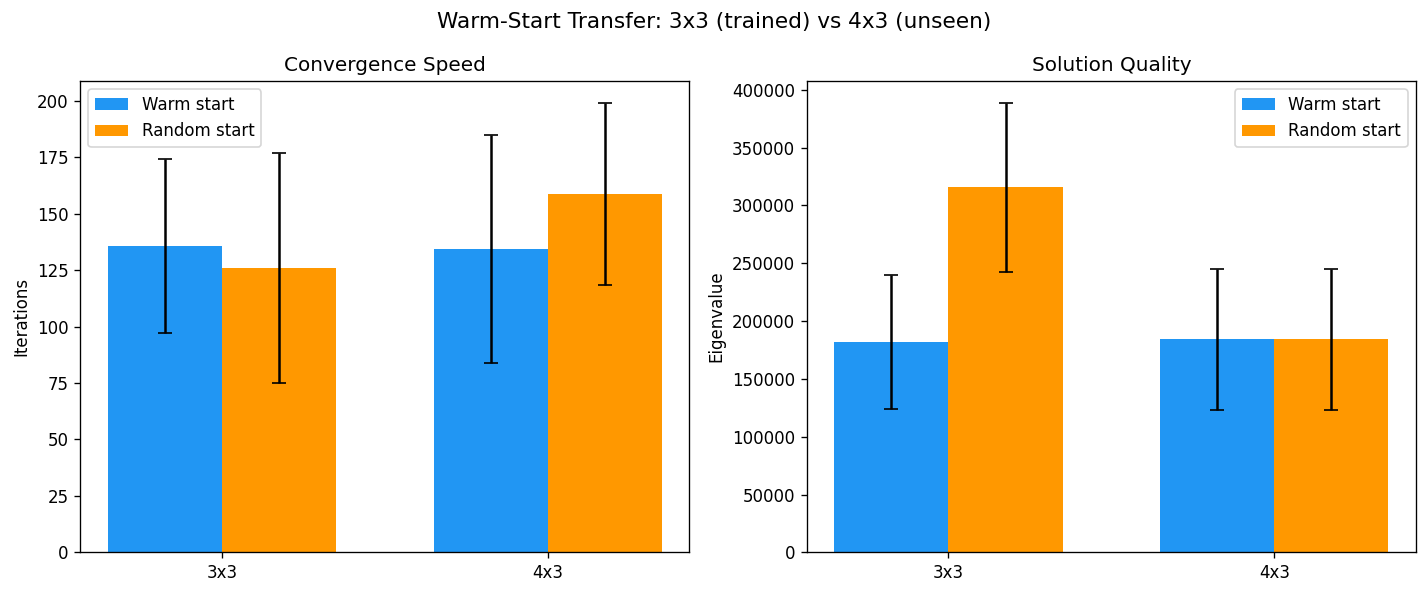

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

configs = ['3x3', '4x3']
x = np.arange(len(configs))
width = 0.35

# --- Iterations subplot ---
ax = axes[0]
warm_iters  = [summary[(c, 'warm')]['iter_mean']   for c in configs]
rand_iters  = [summary[(c, 'random')]['iter_mean'] for c in configs]
warm_ierr   = [summary[(c, 'warm')]['iter_std']    for c in configs]
rand_ierr   = [summary[(c, 'random')]['iter_std']  for c in configs]

ax.bar(x - width/2, warm_iters, width, yerr=warm_ierr,
       label='Warm start', capsize=4, color='#2196F3')
ax.bar(x + width/2, rand_iters, width, yerr=rand_ierr,
       label='Random start', capsize=4, color='#FF9800')
ax.set_ylabel('Iterations')
ax.set_title('Convergence Speed')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()

# --- Eigenvalue subplot ---
ax = axes[1]
warm_eigs  = [summary[(c, 'warm')]['eig_mean']   for c in configs]
rand_eigs  = [summary[(c, 'random')]['eig_mean'] for c in configs]
warm_eerr  = [summary[(c, 'warm')]['eig_std']    for c in configs]
rand_eerr  = [summary[(c, 'random')]['eig_std']  for c in configs]

ax.bar(x - width/2, warm_eigs, width, yerr=warm_eerr,
       label='Warm start', capsize=4, color='#2196F3')
ax.bar(x + width/2, rand_eigs, width, yerr=rand_eerr,
       label='Random start', capsize=4, color='#FF9800')
ax.set_ylabel('Eigenvalue')
ax.set_title('Solution Quality')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()

fig.suptitle('Warm-Start Transfer: 3x3 (trained) vs 4x3 (unseen)', fontsize=13)
fig.tight_layout()
plt.show()

In [8]:
# ---- Speedup / improvement summary ----
print('Iteration speedup  (random / warm):')
for label in ('3x3', '4x3'):
    wi = summary[(label, 'warm')]['iter_mean']
    ri = summary[(label, 'random')]['iter_mean']
    speedup = ri / wi if wi > 0 else float('inf')
    print(f'  {label}: {speedup:.2f}x')

print('\nSaved model files:')
if os.path.isdir(MODEL_DIR):
    for f in sorted(os.listdir(MODEL_DIR)):
        size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
        print(f'  {f}  ({size:.1f} KB)')
else:
    print('  (no models saved yet)')

Iteration speedup  (random / warm):
  3x3: 0.93x
  4x3: 1.18x

Saved model files:
  nx3_ny3_nl6_mtTE_k0.joblib  (1024.6 KB)
  nx3_ny3_nl6_mtTE_k0_scaler.joblib  (0.7 KB)
  nx3_ny3_nl6_mtTE_k1.joblib  (1383.7 KB)
  nx3_ny3_nl6_mtTE_k1_scaler.joblib  (0.7 KB)
  nx3_ny3_nl6_mtTM_k0.joblib  (770.3 KB)
  nx3_ny3_nl6_mtTM_k0_scaler.joblib  (0.7 KB)
  nx3_ny3_nl6_mtTM_k1.joblib  (1038.8 KB)
  nx3_ny3_nl6_mtTM_k1_scaler.joblib  (0.7 KB)
